# LangGraph - LLM Augmentation

> LLM Augmentation & Prompt Chaining

Until now, we have built some basic workflows, but we have not yet used an LLM. In this chapter, we will finally incorporate an LLM into our workflow.

LLMs can be augmented in various ways, such as tool calling, structured outputs, memory, and retrieval in RAG. In agentic workflows, it is common to enhance LLMs using these methods.

![[text](https://langchain-ai.github.io/langgraph/tutorials/workflows/#building-blocks-the-augmented-llm)](assets/img/10-llm-augmentation-1.webp)

Let’s initialize an instance of the `ChatOpenAI` class, and then invoke it with a prompt.

In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")

response = llm.invoke("What are the principles of Atatürk's reforms? List six of them, just give the names of the principles.")
print(response)

content="The six principles of Atatürk's reforms, known as Kemalism, are:\n\n1. Republicanism\n2. Nationalism\n3. Populism\n4. Statism\n5. Secularism\n6. Reformism" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 31, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DLKaWOk5DLJS9rCBRWKSTkXgKGHmT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d093a-1d48-7921-b397-0443d4267c58-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 31, 'output_tokens': 49, 'total_tokens': 80, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning'

This is the simple usage of LLMs.

Now, let’s augment the LLM with the capability to produce structured outputs.

To accomplish this, we first define a Pydantic model that specifies the desired structure.

In [3]:
# Schema for structured output
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )

# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

output

SearchQuery(search_query='Calcium CT score relationship with high cholesterol risk for heart disease', justification='Understanding the relationship between Calcium CT scores and high cholesterol is important for assessing cardiovascular risk. This query will help in exploring how the presence of calcium in coronary arteries, which is evaluated through a Calcium CT score, correlates with cholesterol levels and potential heart disease.')

Using LangChain’s `with_structured_output` method, we augment our LLM to return answers in this format.

Additionally, we can augment our LLM to use tools or call functions.

In [4]:
# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

print(msg)
print()
print(msg.tool_calls)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 48, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cccaf3777', 'id': 'chatcmpl-DLKeTs9s2BWnDWxXpKFu65LZ4bVE7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d093d-dc63-7ed1-81f8-36850f136114-0' tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_n3iK7z8C0pQPdiuE8b0Ty0Yk', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 48, 'output_tokens': 17, 'total_tokens': 65, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}

[{'name': 'multiply', 'args': {'a':

First, we define the function that we want the LLM to call. Then, we use LangChain’s `bind_tools` method to make this function available as a tool. Now, when we ask the model something like *"What is 2 times 3?"*, it will recognize the intent and generate a tool call instead of a plain text response.

Now, let’s create our workflow in LangGraph, where we will make LLM calls within nodes. We will use **prompt chaining** in this workflow, allowing the output of one node to serve as the input for another node’s LLM.

![[text](https://langchain-ai.github.io/langgraph/tutorials/workflows/#building-blocks-the-augmented-llm)](assets/img/10-llm-augmentation-2.webp)

We will design an AI workflow that generates and improves jokes on a given topic.

First, we’ll use a `TypedDict` to specify what information will be tracked at each step. The state will carry the topic, the original joke, an improved version, and the final joke output.

In [12]:
import random
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

llm = ChatOpenAI(model="gpt-4o", temperature=0.8)

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

To construct a step-by-step workflow for joke generation and improvement, we’ll define a series of “nodes” — each responsible for one stage in the creative process.

In [13]:
# Node 1: Generate the initial joke based on the topic
def generate_joke(state: State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}

# Node 2: Decide if the joke is good enough to continue (simulated gate)
def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""
    decision = random.choice(["Pass", "Fail"])  # Simulating a decision for demonstration
    return decision

# Node 3: Make the joke funnier by adding wordplay
def improve_joke(state: State):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}

# Node 4: Polish the joke by adding a twist
def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}

**`generate_joke`**: This node kicks things off by asking the LLM to write a joke about a given topic. It returns the joke as part of the new state.

**`check_punchline`**: Acting as a “gate” node, this function simulates evaluating whether the joke is funny enough to continue. Here, it randomly passes or fails the joke for demonstration, but we could replace this with LLM-based critique or another evaluation mechanism for real applications.

**`improve_joke`**: If the joke passes the gate, this node asks the LLM to enhance the joke using wordplay, aiming to increase its humor.

**`polish_joke`**: Finally, this node refines the joke even further, asking the LLM to introduce a surprising twist to make it even more engaging.

To orchestrate the joke generation and improvement process, a stateful workflow is built where each stage is represented as a node in a graph.

In [14]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", 
    check_punchline, 
    {
        "Fail": "improve_joke",   # If the joke fails, try to improve it
        "Pass": END               # If it passes, finish the workflow
    }
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

Let’s visualize the structure of the workflow.

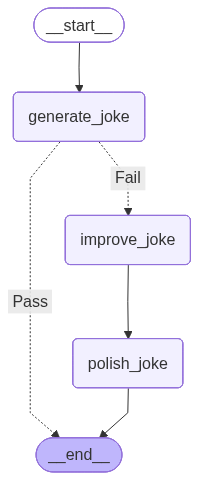

In [15]:
# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

To see our workflow in action, we simply provide an initial state (here, the topic “cats”) and run the compiled chain. The workflow automatically handles each step — generating, checking, possibly improving, and polishing the joke — according to the logic we’ve defined.

In [16]:
# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Passed the punchline check, no improvements needed.")

Initial joke:
Why was the cat sitting on the computer?  

Because it wanted to keep an eye on the mouse!

--- --- ---

Improved joke:
Why was the cat sitting on the computer?  

Because it wanted to keep an eye on the mouse and purr-haps check its feline-stagram!

--- --- ---

Final joke:
Why was the cat sitting on the computer?

Because it wanted to keep an eye on the mouse and purr-haps check its feline-stagram... or maybe it was just downloading the latest version of "Paws of Duty"!


Here, we finally used LLMs in our workflows and demonstrated that we can augment LLMs to provide them with additional capabilities.